In [1]:
list.of.packages <- c("tidyverse","fixest","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose




In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

## Children

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       W_quintile = case_when(Wealth_lowest==1 ~ "Lowest",
                                              Wealth_second==1 ~ "Second",
                                              Wealth_middle==1 ~ "Middle",
                                              Wealth_fourth==1 ~ "Fourth",
                                              Wealth_highest==1 ~ "Highest",
                                              TRUE ~ NA),
                       W_quintile=factor(W_quintile,levels=c("Lowest","Second","Middle","Fourth","Highest"))
                )

## Women

In [5]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [6]:
df_reg_women <- df_women %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       W_quintile = case_when(Wealth_lowest==1 ~ "Lowest",
                                              Wealth_second==1 ~ "Second",
                                              Wealth_middle==1 ~ "Middle",
                                              Wealth_fourth==1 ~ "Fourth",
                                              Wealth_highest==1 ~ "Highest",
                                              TRUE ~ NA),
                       W_quintile=factor(W_quintile,levels=c("Lowest","Second","Middle","Fourth","Highest"))
                )

# Men

In [7]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [8]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       W_quintile = case_when(Wealth_lowest==1 ~ "Lowest",
                                              Wealth_second==1 ~ "Second",
                                              Wealth_middle==1 ~ "Middle",
                                              Wealth_fourth==1 ~ "Fourth",
                                              Wealth_highest==1 ~ "Highest",
                                              TRUE ~ NA),
                       W_quintile=factor(W_quintile,levels=c("Lowest","Second","Middle","Fourth","Highest"))
                )

# Air temperature

In [9]:
reg_children_T <- feols(Child_hemo_level_alti ~ W_quintile + i(T_i30_bin,W_quintile, ref=bin_ref_T) + P_tot_30 +
                                        Child_female + Child_birth_order + Child_alive_age_month + 
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        #Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                    vcov = ~District_ID,
                    df_reg_children)

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).



In [10]:
reg_women_T <- feols(Blood_hemo_level_alti ~  W_quintile + i(T_i30_bin,W_quintile, ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        #Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                    vcov = ~District_ID,
                    df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [11]:
reg_men_T <- feols(Blood_hemo_level_alti ~  W_quintile + i(T_i30_bin,W_quintile, ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        #Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                    vcov = ~District_ID,
                    df_reg_men)

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [12]:
varT <- "T_i30_bin"

dict <- setNames(paste0("Air T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))

In [13]:
etable(reg_children_T,reg_women_T,reg_men_T,
       tex=TRUE,
       fitstat = ~ n + r2 + my,
       drop="%!_quintile",
       dict=dict
      )

\begingroup
\centering
\begin{tabular}{lccc}
   \tabularnewline \midrule \midrule
   Dependent Variables: & Child\_hemo\_level\_alti & \multicolumn{2}{c}{Blood\_hemo\_level\_alti}\\
   Model:                                            & (1)            & (2)             & (3)\\  
   \midrule
   \emph{Variables}\\
   W\_quintileSecond                                 & 0.4214$^{*}$   & 0.6029$^{***}$  & 1.437$^{***}$\\   
                                                     & (0.2444)       & (0.2037)        & (0.4657)\\   
   W\_quintileMiddle                                 & 0.5603$^{*}$   & 1.171$^{***}$   & 2.033$^{***}$\\   
                                                     & (0.3051)       & (0.2400)        & (0.5441)\\   
   W\_quintileFourth                                 & 1.154$^{***}$  & 1.400$^{***}$   & 3.445$^{***}$\\   
                                                     & (0.3059)       & (0.2777)        & (0.6802)\\   
   W\_quintileHighest                          

# Extract estimates

In [14]:
quintile_list <- c("Lowest","Second","Middle","Fourth","Highest")

In [15]:
groups <- c("Children","Men","Women")

In [16]:
extract_estimate <- function(df,group_name,quintile_name,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(quintile_name,term))%>% 
                         mutate(quintile = quintile_name, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [17]:
children_estimates <- data.frame()
for (quintile_name in quintile_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_children_T,"Children",quintile_name,Tbin_name)
        children_estimates <- rbind(children_estimates,row_estimate)
        }
    }

In [18]:
women_estimates <- data.frame()
for (quintile_name in quintile_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_women_T,"Women",quintile_name,Tbin_name)
        women_estimates <- rbind(women_estimates,row_estimate)
        }
    }

In [19]:
men_estimates <- data.frame()
for (quintile_name in quintile_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_men_T,"Men",quintile_name,Tbin_name)
        men_estimates <- rbind(men_estimates,row_estimate)
        }
    }

In [20]:
all_estimates <- rbind(children_estimates,women_estimates,men_estimates) %>%
                   mutate(quintile=factor(quintile,levels=c("Lowest","Second","Middle","Fourth","Highest")),
                          Tbin=factor(Tbin,levels=T_bins_labels))
all_estimates

term,estimate,std.error,statistic,p.value,conf.low,conf.high,quintile,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>
T_i30_bin::<=17°C:W_quintile::Lowest,-1.0123534602,0.4569363,-2.215524483,2.707582e-02,-1.90963159,-0.115075330,Lowest,Children,<=17°C
"T_i30_bin::21,23]:W_quintile::Lowest",0.2725095998,0.4357557,0.625372464,5.319499e-01,-0.58317658,1.128195776,Lowest,Children,"21,23]"
"T_i30_bin::23,25]:W_quintile::Lowest",-0.7614206070,0.4370914,-1.742016911,8.198664e-02,-1.61972972,0.096888507,Lowest,Children,"23,25]"
"T_i30_bin::25,27]:W_quintile::Lowest",-1.5377659106,0.5162877,-2.978505949,3.006375e-03,-2.55159144,-0.523940384,Lowest,Children,"25,27]"
"T_i30_bin::27,29]:W_quintile::Lowest",-2.2792930574,0.5820868,-3.915726793,9.982452e-05,-3.42232732,-1.136258792,Lowest,Children,"27,29]"
"T_i30_bin::29,31]:W_quintile::Lowest",-3.2941532499,0.7159757,-4.600928797,5.073797e-06,-4.70010285,-1.888203652,Lowest,Children,"29,31]"
"T_i30_bin::31,33]:W_quintile::Lowest",-3.6348144920,0.7861396,-4.623624763,4.564913e-06,-5.17854375,-2.091085237,Lowest,Children,"31,33]"
T_i30_bin::>33°C:W_quintile::Lowest,-3.4671571642,0.8988250,-3.857432739,1.262002e-04,-5.23216497,-1.702149356,Lowest,Children,>33°C
T_i30_bin::<=17°C:W_quintile::Second,-0.7683157782,0.3931962,-1.954026405,5.113394e-02,-1.54042864,0.003797086,Second,Children,<=17°C


# Plot

In [21]:
theme_perso <- function(...){
                          theme(plot.title = element_text(size = 30, face="bold",hjust=0.5),
                                plot.subtitle = element_text(size = 28),
                                legend.position="top",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 18,angle=45,hjust=1),
                                axis.text.y = element_text(size = 18),
                                axis.title.x = element_text(size = 20, hjust = 0.5),
                                axis.title.y = element_text(size = 20, hjust = 0.5))
}

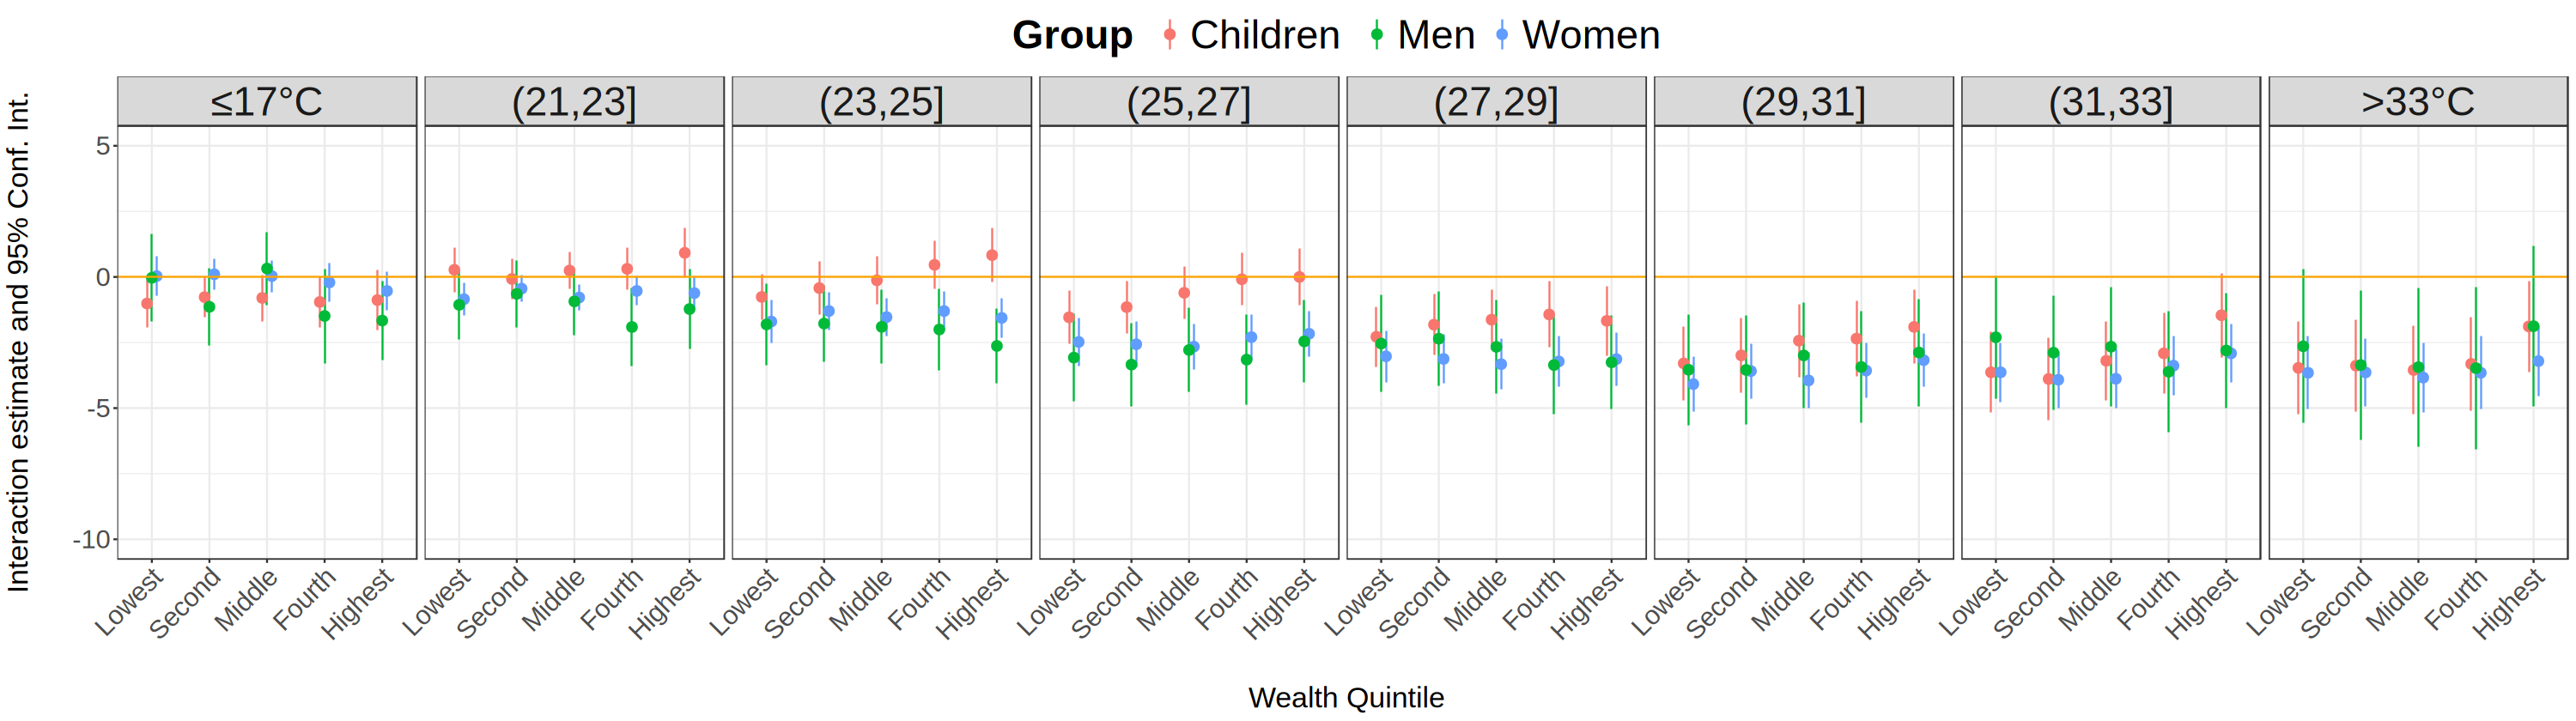

In [22]:
options(repr.plot.width=25, repr.plot.height=7, scipen=9999)

plot_estimates <- ggplot(all_estimates,aes(x=quintile, y=estimate, ymin=conf.low, ymax=conf.high, color=group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Hemoglobin level (g/L) - Interaction wealth quintile and air temperature bin \n",
                               x="\n Wealth Quintile", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          coord_cartesian(y=c(-10,5))+
                          facet_grid(cols = vars(Tbin),
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()
plot_estimates

In [23]:
ggsave("./3_output/img/hetero_wealth_hemo.png", width=25, height=7, plot_estimates)